# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [1]:
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.typing import NDArray


def load_data(path: str | Path) -> pd.DataFrame:
    return pd.read_csv(path)


df = load_data("delivery_dataset.csv")
df.head(10)

,Дата заказа (ГГГГ-ММ-ДД),Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах)
0,2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2
1,2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6
2,2026-08-15,ORD-202608003,2.2,1,3,20.0,5,16.3
3,2026-08-08,ORD-202608004,0.9,2,6,22.9,1,15.8
4,2026-08-21,ORD-202608005,12.3,14,4,18.1,2,69.2
5,2026-09-08,ORD-202608006,5.5,1,3,20.7,5,28.9
6,2026-08-19,ORD-202608007,11.7,3,7,9.4,2,66.0
7,2026-08-23,ORD-202608008,0.8,4,1,13.1,1,11.0
8,2026-08-11,ORD-202608009,11.0,5,8,15.2,15,77.7
9,2026-08-11,ORD-202608010,0.8,4,4,17.4,23,26.0


#### Шаг 2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих;
* в тестовой: 100 последних.

In [2]:
def split_data(
    df: pd.DataFrame,
    features: list[str],
    target: str,
    train_size: int = 300,
    val_size: int = 100,
) -> tuple[
    NDArray[np.float64],
    NDArray[np.float64],
    NDArray[np.float64],
    NDArray[np.float64],
    NDArray[np.float64],
    NDArray[np.float64],
]:
    X = df[features].to_numpy(dtype=np.float64)
    y = df[target].to_numpy(dtype=np.float64)
    return (
        X[:train_size],
        y[:train_size],
        X[train_size : train_size + val_size],
        y[train_size : train_size + val_size],
        X[train_size + val_size :],
        y[train_size + val_size :],
    )


features = [
    "Расстояние до клиента (в км)",
    "Количество позиций в чеке (в шт.)",
    "Балл пробок на дорогах (в баллах)",
    "Погода (в градусах Цельсия)",
    "Этаж доставки (в этажах)",
]
target = "Время доставки (в минутах)"

X_train, y_train, X_val, y_val, X_test, y_test = split_data(df, features, target)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (300, 5) (300,)
Val:   (100, 5) (100,)
Test:  (100, 5) (100,)


#### Вопрос 1.

Для чего мы разбиваем данные на выборки? Для чего нам нужна тренировочная, для чего валидационная, для чего тестовая?

**Ответ:** разбиение позволяет честно оценить качество модели на новых, невиданных ею данных. На тренировочной выборке модель подстраивает веса под закономерности; на валидационной мы проверяем, не произошло ли переобучение, и выбираем гиперпараметры; тестовая выборка нужна для финальной, максимально объективной оценки — её модель не видела ни разу за всё время обучения и подбора параметров.

#### Шаг 3. Импортируйте инструменты для Ridge-регрессии

In [3]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler


def scale_features(
    X_train: NDArray[np.float64],
    X_val: NDArray[np.float64],
    X_test: NDArray[np.float64],
) -> tuple[NDArray[np.float64], NDArray[np.float64], NDArray[np.float64], StandardScaler]:
    scaler = StandardScaler()
    return (
        scaler.fit_transform(X_train),  # type: ignore
        scaler.transform(X_val),
        scaler.transform(X_test),
        scaler,
    )


def fit_ridge(
    X_train: NDArray[np.float64],
    y_train: NDArray[np.float64],
    *,
    alpha: float = 1.0,
    solver: Literal["sparse_cg"] = "sparse_cg",
) -> Ridge:
    model = Ridge(alpha=alpha, solver=solver)
    model.fit(X_train, y_train)
    return model


def compute_errors(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> dict[str, float]:
    err = y_true - y_pred
    sse = float(np.sum(err**2))
    mse = float(np.mean(err**2))
    return {"sse": sse, "mse": mse, "rmse": float(np.sqrt(mse))}

#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [4]:
X_train_s, X_val_s, X_test_s, scaler = scale_features(X_train, X_val, X_test)

ridge = fit_ridge(X_train_s, y_train, alpha=1.0)

print("Коэффициенты:", ridge.coef_)
print("Свободный член:", ridge.intercept_)

train_metrics = compute_errors(y_train, ridge.predict(X_train_s))
val_metrics = compute_errors(y_val, ridge.predict(X_val_s))
print("SSE на train:", train_metrics["sse"])
print("RMSE train:", train_metrics["rmse"])
print("RMSE val:  ", val_metrics["rmse"])

Коэффициенты: [25.4834848   2.59300992  4.80830946 -0.27691823  2.16614125]
Свободный член: 42.82933333333333
SSE на train: 5531.437445059115
RMSE train: 4.293963765201532
RMSE val:   4.568607250829681


#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

In [5]:
def add_bias(X: NDArray[np.float64]) -> NDArray[np.float64]:
    return np.c_[np.ones(X.shape[0]), X]


def train_gradient_descent(
    X_train: NDArray[np.float64],
    y_train: NDArray[np.float64],
    X_val: NDArray[np.float64],
    y_val: NDArray[np.float64],
    *,
    alpha: float = 1.0,
    lr: float = 1e-4,
    max_iter: int = 10_000,
    epsilon: float = 1e-3,
) -> tuple[NDArray[np.float64], dict[str, list[float]], dict[str, list[float]]]:
    X_train_b = add_bias(X_train)
    X_val_b = add_bias(X_val)

    weights = np.zeros(X_train_b.shape[1], dtype=np.float64)

    train_hist: dict[str, list[float]] = {"sse": [], "mse": [], "rmse": []}
    val_hist: dict[str, list[float]] = {"sse": [], "mse": [], "rmse": []}

    prev_loss = float("inf")

    for it in range(max_iter):
        pred_train = X_train_b @ weights
        pred_val = X_val_b @ weights

        train_metrics = compute_errors(y_train, pred_train)
        val_metrics = compute_errors(y_val, pred_val)

        train_hist["sse"].append(train_metrics["sse"])
        train_hist["mse"].append(train_metrics["mse"])
        train_hist["rmse"].append(train_metrics["rmse"])
        val_hist["sse"].append(val_metrics["sse"])
        val_hist["mse"].append(val_metrics["mse"])
        val_hist["rmse"].append(val_metrics["rmse"])

        loss = train_metrics["sse"] + alpha * float(np.sum(weights[1:] ** 2))

        if abs(prev_loss - loss) < epsilon:
            print(f"Остановка на итерации {it}: |J_t - J_{{t-1}}| < {epsilon}")
            break
        prev_loss = loss

        err_train = y_train - pred_train
        grad = -2 * X_train_b.T @ err_train
        grad[1:] += 2 * alpha * weights[1:]
        weights -= lr * grad
    else:
        print(f"Достигнуто максимальное число итераций ({max_iter})")

    return weights, train_hist, val_hist


w, train_hist, val_hist = train_gradient_descent(
    X_train_s,
    y_train,
    X_val_s,
    y_val,
    alpha=1.0,
    lr=0.0001,
    max_iter=10_000,
    epsilon=0.001,
)

print("Итоговые веса:", w)
print("Итоговый RMSE train:", train_hist["rmse"][-1])
print("Итоговый RMSE val:  ", val_hist["rmse"][-1])

Остановка на итерации 151: |J_t - J_{t-1}| < 0.001
Итоговые веса: [42.8255832  25.48074901  2.59351308  4.80712405 -0.27787805  2.16624817]
Итоговый RMSE train: 4.294023655360043
Итоговый RMSE val:   4.568091973584514


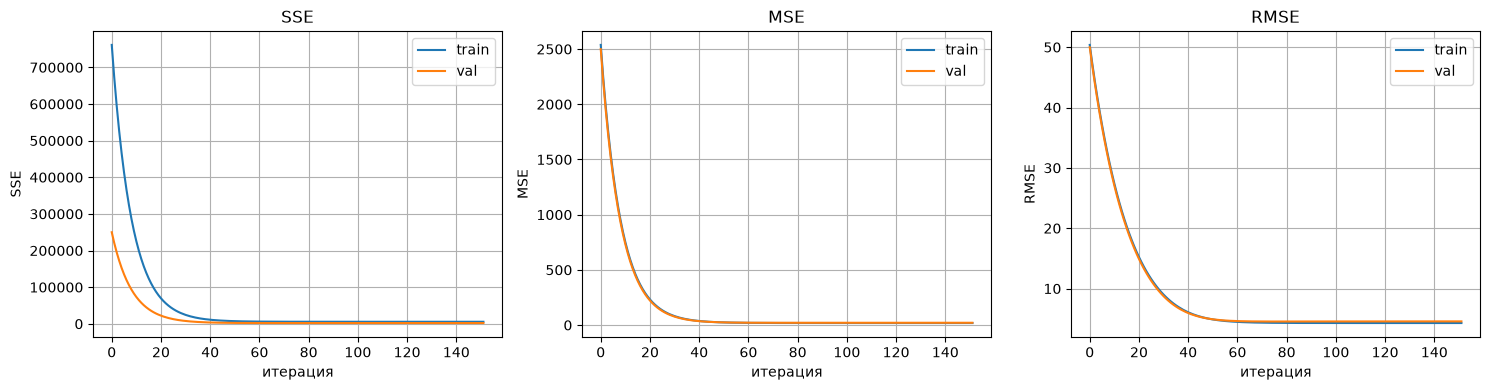

In [6]:
def plot_errors(
    train_hist: dict[str, list[float]],
    val_hist: dict[str, list[float]],
) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # type: ignore

    for ax, metric in zip(axes, ["sse", "mse", "rmse"], strict=False):
        ax.plot(train_hist[metric], label="train")
        ax.plot(val_hist[metric], label="val")
        ax.set_title(metric.upper())
        ax.set_xlabel("итерация")
        ax.set_ylabel(metric.upper())
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()  # type: ignore


plot_errors(train_hist, val_hist)

#### Вопрос 2.

Какую информацию про нашу модель несут эти графики?

**Ответ:** графики показывают динамику обучения модели. По ним видно, сходится ли алгоритм (ошибки падают и выходят на плато), насколько быстро это происходит, и нет ли признаков переобучения — когда ошибка на train продолжает падать, а на val начинает расти.

#### Вопрос 3.

Какая траектория линий train и val ошибок будет на графиках недообученной модели и почему?

**Ответ:** на недообученной модели обе ошибки останутся высокими и не будут снижаться до приемлемого уровня — модель слишком простая и не смогла уловить зависимости в данных даже на train.

Какая траектория линий train и val ошибок будет на графиках обученной модели и почему?

**Ответ:** на обученной модели обе ошибки будут снижаться и стабилизируются на низком уровне, при этом val будет близка к train — модель обобщает закономерности, а не запоминает шум.

Какая траектория линий train и val ошибок будет на графиках переобученной модели и почему?

**Ответ:** на переобученной модели ошибка train будет продолжать падать до очень низких значений, а ошибка val с некоторого момента начнёт расти — модель запомнила шум и особенности тренировочной выборки, потеряв способность обобщать.

#### Шаг 6. Применение модели на тестовой выборке

In [7]:
def make_predictions(
    df: pd.DataFrame,
    X_test: NDArray[np.float64],
    y_test: NDArray[np.float64],
    weights: NDArray[np.float64],
    id_col: str = "Шифр заказа (ID)",
) -> pd.DataFrame:
    y_pred_test = add_bias(X_test) @ weights
    results = pd.DataFrame(
        {
            "order id": df[id_col].iloc[-len(y_test) :].to_numpy(),
            "predicted time": y_pred_test,
            "real time": y_test,
            "difference": y_pred_test - y_test,
        }
    )
    return results.round(2)


results = make_predictions(df, X_test_s, y_test, w)
results.to_csv("test_predictions.csv", index=False)
results.head(10)

,order id,predicted time,real time,difference
0,ORD-202608401,33.10,33.9,-0.80
1,ORD-202608402,33.15,33.1,0.05
2,ORD-202608403,20.92,16.3,4.62
3,ORD-202608404,34.41,34.7,-0.29
4,ORD-202608405,17.65,13.3,4.35
5,ORD-202608406,42.81,39.3,3.51
6,ORD-202608407,37.47,36.3,1.17
7,ORD-202608408,12.45,11.9,0.55
8,ORD-202608409,59.00,56.5,2.50
9,ORD-202608410,32.13,35.9,-3.77


#### Шаг 7. RMSE на тестовой выборке

In [8]:
test_metrics = compute_errors(y_test, add_bias(X_test_s) @ w)
print(f"Test SSE:  {test_metrics['sse']:.2f}")
print(f"Test MSE:  {test_metrics['mse']:.2f}")
print(f"Test RMSE: {test_metrics['rmse']:.2f}")

Test SSE:  2346.92
Test MSE:  23.47
Test RMSE: 4.84


#### Вопрос 4.

Что получившийся RMSE может сказать о нашей модели?

**Ответ:** RMSE показывает среднеквадратичную ошибку в единицах целевой переменной — минутах. Чем он ниже относительно разброса целевой переменной, тем точнее модель предсказывает время доставки. Если RMSE сопоставим со стандартным отклонением y_test, модель практически не несёт полезного сигнала; если значительно ниже — она уловила реальные зависимости.